# Optimización de gastos de marketing de *Showz*

En el departamento de analítica de *Showz*, se pidió realizar una serie de acciones y análisis para optimizar los gastos de marketing, con el propósito de enfocar mejor los gastos en acciones más rentables

## Carga de datos

Para comenzar, primero se cargaron los *datasets* que contiene datos de visitas, pedidos y gastos variables.

In [1]:
import pandas as pd

In [2]:
visits_log = pd.read_csv('visits_log_us.csv')
orders_log = pd.read_csv('orders_log_us.csv')
costs = pd.read_csv('costs_us.csv')

## Información general

Lo siguiente es una muestra de los datos para su análisis, y posible limpieza de datos con el objetivo de poder trabajar los datos de forma limpia y correcta

In [3]:
print(visits_log.head(10))

    Device               End Ts  Source Id             Start Ts  \
0    touch  2017-12-20 17:38:00          4  2017-12-20 17:20:00   
1  desktop  2018-02-19 17:21:00          2  2018-02-19 16:53:00   
2    touch  2017-07-01 01:54:00          5  2017-07-01 01:54:00   
3  desktop  2018-05-20 11:23:00          9  2018-05-20 10:59:00   
4  desktop  2017-12-27 14:06:00          3  2017-12-27 14:06:00   
5  desktop  2017-09-03 21:36:00          5  2017-09-03 21:35:00   
6  desktop  2018-01-30 12:09:00          1  2018-01-30 11:13:00   
7    touch  2017-11-05 15:15:00          3  2017-11-05 15:14:00   
8  desktop  2017-07-19 10:44:00          3  2017-07-19 10:41:00   
9  desktop  2017-11-08 13:43:00          5  2017-11-08 13:42:00   

                    Uid  
0  16879256277535980062  
1    104060357244891740  
2   7459035603376831527  
3  16174680259334210214  
4   9969694820036681168  
5  16007536194108375387  
6   6661610529277171451  
7  11423865690854540312  
8   2987360259350925644  
9 

In [4]:
print(orders_log.head(10))

                Buy Ts  Revenue                   Uid
0  2017-06-01 00:10:00    17.00  10329302124590727494
1  2017-06-01 00:25:00     0.55  11627257723692907447
2  2017-06-01 00:27:00     0.37  17903680561304213844
3  2017-06-01 00:29:00     0.55  16109239769442553005
4  2017-06-01 07:58:00     0.37  14200605875248379450
5  2017-06-01 08:43:00     0.18  10402394430196413321
6  2017-06-01 08:54:00     1.83  12464626743129688638
7  2017-06-01 09:22:00     1.22   3644482766749211722
8  2017-06-01 09:22:00     3.30  17542070709969841479
9  2017-06-01 09:23:00     0.37   1074355127080856382


In [5]:
print(costs.head(10))

   source_id          dt  costs
0          1  2017-06-01  75.20
1          1  2017-06-02  62.25
2          1  2017-06-03  36.53
3          1  2017-06-04  55.00
4          1  2017-06-05  57.08
5          1  2017-06-06  40.39
6          1  2017-06-07  40.59
7          1  2017-06-08  56.63
8          1  2017-06-09  40.16
9          1  2017-06-10  43.24


## Visitas

### Filtrar por usuarios únicos por día
Lo primero que se realizó fue filtrar los datos a usuarios únicos por día, esto sirve como base a la frecuencia que usan los usuarios. asdi como hya una visualización  de gráfico de líneas para mostrar el comportamiento.
Se han registrado muchos usuarios únicos entre noviembre y diciembre de 2017

<AxesSubplot:title={'center':'Usuarios Únicos por Día'}, xlabel='date'>

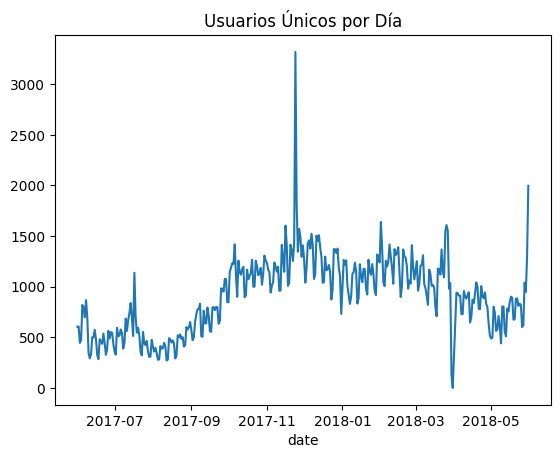

In [6]:
visits_log['Start Ts'] = pd.to_datetime(visits_log['Start Ts'])
visits_log['End Ts'] = pd.to_datetime(visits_log['End Ts'])
visits_log['date'] = visits_log['Start Ts'].dt.date

usuarios_unicos_por_dia = visits_log.groupby('date')['Uid'].nunique()

usuarios_unicos_por_dia.plot(kind='line', title='Usuarios Únicos por Día')

### Periodicidad

La periodicidad muestra los patrones regulares en el comportamiento de los usuarios, por ende de prepararon los Datos para el Análisis de Periodicidad agregandose columnas de tiempo. 

In [7]:
# Agregación de columnas de tiempo para análisis de periodicidad
visits_log['day_of_week'] = visits_log['Start Ts'].dt.day_name()
visits_log['week'] = visits_log['Start Ts'].dt.isocalendar().week
visits_log['month'] = visits_log['Start Ts'].dt.month
visits_log['month_name'] = visits_log['Start Ts'].dt.month_name()

Se verificó si las nuevas columnas se crearon correctamente

In [8]:
# Verificación de las nuevas columnas
print("Columnas creadas:")
print(visits_log[['Start Ts', 'day_of_week', 'week', 'month', 'month_name']].head())

Columnas creadas:
             Start Ts day_of_week  week  month month_name
0 2017-12-20 17:20:00   Wednesday    51     12   December
1 2018-02-19 16:53:00      Monday     8      2   February
2 2017-07-01 01:54:00    Saturday    26      7       July
3 2018-05-20 10:59:00      Sunday    20      5        May
4 2017-12-27 14:06:00   Wednesday    52     12   December


### Visualizaciones de periodicidad

Se crearon al menos 2 visualizaciones de cada periodo de tiempo, una para los usuarios únicos por día de la semana y otro para los usuarios únicos por mes

*   Usuarios únicos por día de la semana

La tabla muestra que los jueves es donde hay más usuarios únicos que los fines de semana

<AxesSubplot:title={'center':'Usuarios Únicos por Día de la Semana'}, xlabel='day_of_week'>

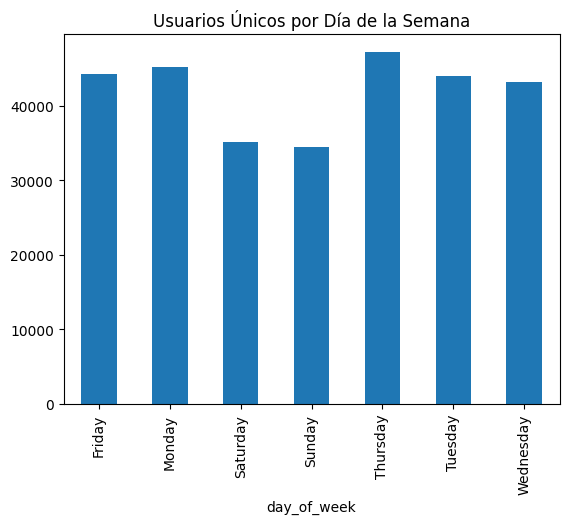

In [9]:
usuarios_por_dia_semana = visits_log.groupby('day_of_week')['Uid'].nunique()
usuarios_por_dia_semana.plot(kind='bar', title='Usuarios Únicos por Día de la Semana')

*   Usuarios únicos por mes

Tanto los últimos 3 meses del año (especiamente noviembre), y los primeros 3 del año, es donde hay más usuarios únicos

<AxesSubplot:title={'center':'Usuarios Únicos por Mes'}, xlabel='month_name'>

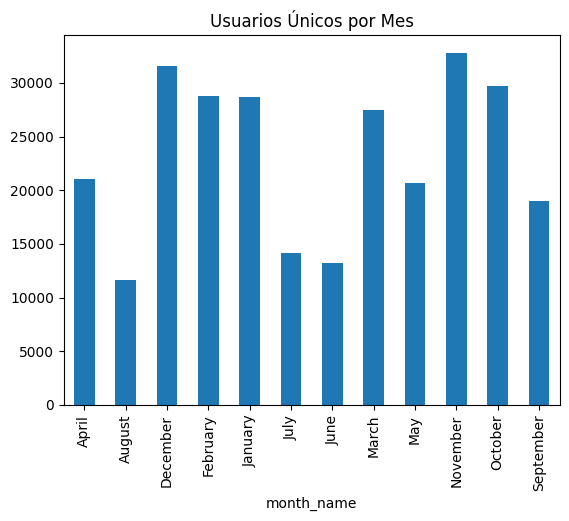

In [10]:
usuarios_por_mes = visits_log.groupby('month_name')['Uid'].nunique()
usuarios_por_mes.plot(kind='bar', title='Usuarios Únicos por Mes')

### Cantidad de sesiones

La cantidad de sesiones son aquellos que entraron en la plataforma, en todas las sesiones, hubo un total de **228 169** usuarios únicos

In [11]:

#cuántos usuarios únicos hubo
usuarios_unicos = visits_log.groupby('Uid').nunique().count()
print("Usuarios únicos:")
print(usuarios_unicos)


Usuarios únicos:
Device         228169
End Ts         228169
Source Id      228169
Start Ts       228169
date           228169
day_of_week    228169
week           228169
month          228169
month_name     228169
dtype: int64


<AxesSubplot:title={'center':'Sesiones por día'}, xlabel='date'>

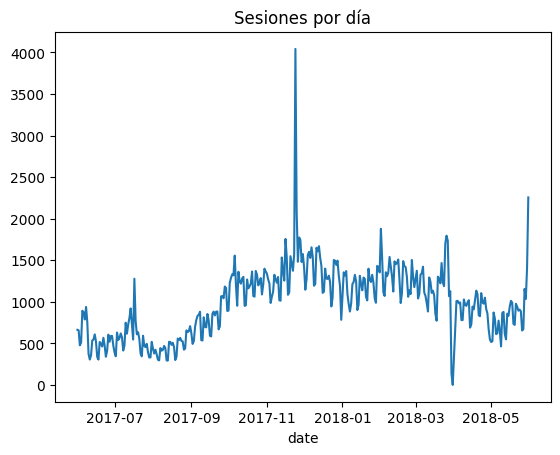

In [12]:
#
visits_log['Start Ts'] = pd.to_datetime(visits_log['Start Ts'])
visits_log['End Ts'] = pd.to_datetime(visits_log['End Ts'])
visits_log['date'] = visits_log['Start Ts'].dt.date

sesiones_por_dia = visits_log.groupby('date')['Uid'].count()

sesiones_por_dia.plot(kind='line', title='Sesiones por día')


En el gráfico de arriba, cada usuario tiene exactamente UNA sesión por día

**En otras palabras:** los usuarios que visitan el sitio en un día específico NO regresan ese mismo día.

### Verificación de hipótesis

Se ejecutó un código agrupando la fecha y los usuarios para averiguar la cantidad de sesiones por usuarios únicos

In [13]:
sesiones_por_usuario_por_dia = visits_log.groupby(['date', 'Uid']).size()
usuarios_con_multiples_sesiones = sesiones_por_usuario_por_dia[sesiones_por_usuario_por_dia > 1]

print("Usuarios con múltiples sesiones el mismo día:")
print(usuarios_con_multiples_sesiones.head(10))
print(f"\nTotal de casos: {len(usuarios_con_multiples_sesiones)}")

Usuarios con múltiples sesiones el mismo día:
date        Uid                
2017-06-01  184148767273119549     2
            585738041899923335     2
            736593129405945093     2
            1186757012633220834    2
            1210481103526146221    2
            1292867924428534308    2
            1548840741623289234    2
            1899944045327801997    2
            2050423809815667474    3
            2802806506908037623    2
dtype: int64

Total de casos: 22572


*   ¿Qué significa esto para Showz?
Si efectivamente no hay usuarios con múltiples sesiones por día

*   ¿Esto, qué podría indicar?:

Un comportamiento de "una visita por día": Los usuarios entran, hacen lo que necesitan, y se van

*   Posible área de mejora:

¿Podrían los usuarios beneficiarse de regresar el mismo día?

### Duración de cada sesión

Se hizo un cálculo para identificar la duración promedio de cada sesión, y se descubrió que la visita promedio es de **10 minutos**, y la gran mayoría visita el sitio una vez

In [14]:
# Calcular duración en minutos (End Ts - Start Ts)
visits_log['session_duration_min'] = (visits_log['End Ts'] - visits_log['Start Ts']).dt.total_seconds() / 60

# Calcular duración en segundos
visits_log['session_duration_sec'] = (visits_log['End Ts'] - visits_log['Start Ts']).dt.total_seconds()

print(f"Duración promedio de cada sesión en minutos: {visits_log['session_duration_min'].mean():.2f} minutos")

# Crear histograma

Duración promedio de cada sesión en minutos: 10.72 minutos


In [15]:
# Contar el número total de visitas por usuario
visitas_por_usuario = visits_log.groupby('Uid').size()

print("Distribución de número de visitas por usuario:")
print(visitas_por_usuario.value_counts().sort_index().head(10))

Distribución de número de visitas por usuario:
1     176041
2      30926
3      10184
4       4357
5       2283
6       1243
7        807
8        513
9        356
10       239
dtype: int64


### frecuencia con la que los usuarios regresan: usuarios nuevos vs. recurrentes

Un usuario recurrente es aquel que visita más de una vez, sin embargo, esto mismo no es suficiente, se necesita saber cúantos visitan nuevamente, y con qué frecuencia, es por ello que se hizo un cálculo pra ebcibtrar la frecuencia de visitas

In [16]:
# Clasificar usuarios como nuevos (1 visita) vs recurrentes (2+ visitas)
usuarios_nuevos = (visitas_por_usuario == 1).sum()
usuarios_recurrentes = (visitas_por_usuario >= 2).sum()

print(f"Usuarios nuevos (1 visita): {usuarios_nuevos:,}")
print(f"Usuarios recurrentes (2+ visitas): {usuarios_recurrentes:,}")
print(f"Total de usuarios: {len(visitas_por_usuario):,}")

# Calcular porcentajes
porcentaje_nuevos = (usuarios_nuevos / len(visitas_por_usuario)) * 100
porcentaje_recurrentes = (usuarios_recurrentes / len(visitas_por_usuario)) * 100

print(f"\nPorcentaje de usuarios nuevos: {porcentaje_nuevos:.1f}%")
print(f"Porcentaje de usuarios recurrentes: {porcentaje_recurrentes:.1f}%")

Usuarios nuevos (1 visita): 176,041
Usuarios recurrentes (2+ visitas): 52,128
Total de usuarios: 228,169

Porcentaje de usuarios nuevos: 77.2%
Porcentaje de usuarios recurrentes: 22.8%


 El cálculo muestra que 176,041 usuarios visitaron solo 1 vez y 30,926 visitaron 2 veces. Por ende, los usuarios recurrentes son aquellos que visitan más de 1 vez

### Graficación

Se realizó una gráfica de pastel, para mostrar los resultados obtenidos de los usuarios recurrentes

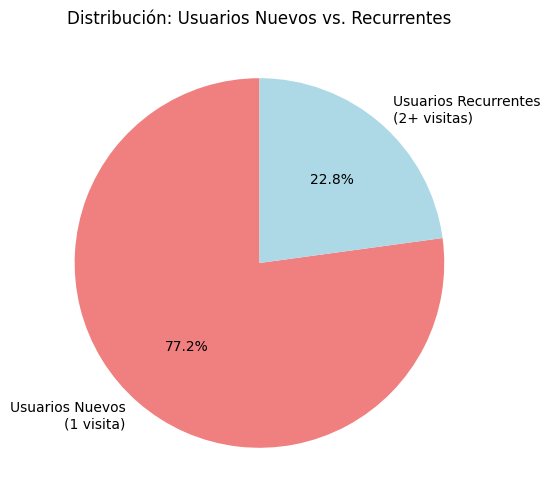

In [18]:
import matplotlib.pyplot as plt

# Crear gráfico de pastel
labels = ['Usuarios Nuevos\n(1 visita)', 'Usuarios Recurrentes\n(2+ visitas)']
sizes = [usuarios_nuevos, usuarios_recurrentes]
colors = ['lightcoral', 'lightblue']

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Distribución: Usuarios Nuevos vs. Recurrentes')
plt.show()

La gran mayoría de los usuarios (77.2 %) son usuarios nuevos, algunos cuantos visitan en promedio 2 veces la página, esto puede afectar a Showz, ya que no le generan mucho beneficio que los usuarios visiten una vez,  es importante cambair la estrategia para hacer que los usuarios nuevos sean más recurrentes  
¿Esto es bueno o malo para Showz?
¿Qué estrategias podrían ayudar a convertir más usuarios nuevos en recurrentes?

### Frecuencia de retorno

Se analizaron cuántos días pasan entre las visitas de los usuarios recurrentes, así como se hizo un gráfico de barras para mostrar visualmente cuál es el patrón de retorno

In [20]:
# Analizar solo usuarios recurrentes (2+ visitas)
usuarios_recurrentes_ids = visitas_por_usuario[visitas_por_usuario >= 2].index

# Filtrar datos solo de usuarios recurrentes
visits_recurrentes = visits_log[visits_log['Uid'].isin(usuarios_recurrentes_ids)]

# Calcular días entre visitas para cada usuario
def calcular_dias_entre_visitas(user_data):
    fechas = sorted(user_data['date'].unique())
    if len(fechas) < 2:
        return []
    
    dias_entre_visitas = []
    for i in range(1, len(fechas)):
        dias = (pd.to_datetime(fechas[i]) - pd.to_datetime(fechas[i-1])).days
        dias_entre_visitas.append(dias)
    
    return dias_entre_visitas

# Aplicar función a cada usuario recurrente
todos_los_intervalos = []
for uid in usuarios_recurrentes_ids:
    user_data = visits_recurrentes[visits_recurrentes['Uid'] == uid]
    intervalos = calcular_dias_entre_visitas(user_data)
    todos_los_intervalos.extend(intervalos)

print(f"Total de intervalos entre visitas: {len(todos_los_intervalos)}")

Total de intervalos entre visitas: 102340


Promedio de días entre visitas: 36.0 días
Mediana de días entre visitas: 12.0 días
Intervalo más común: 1 días


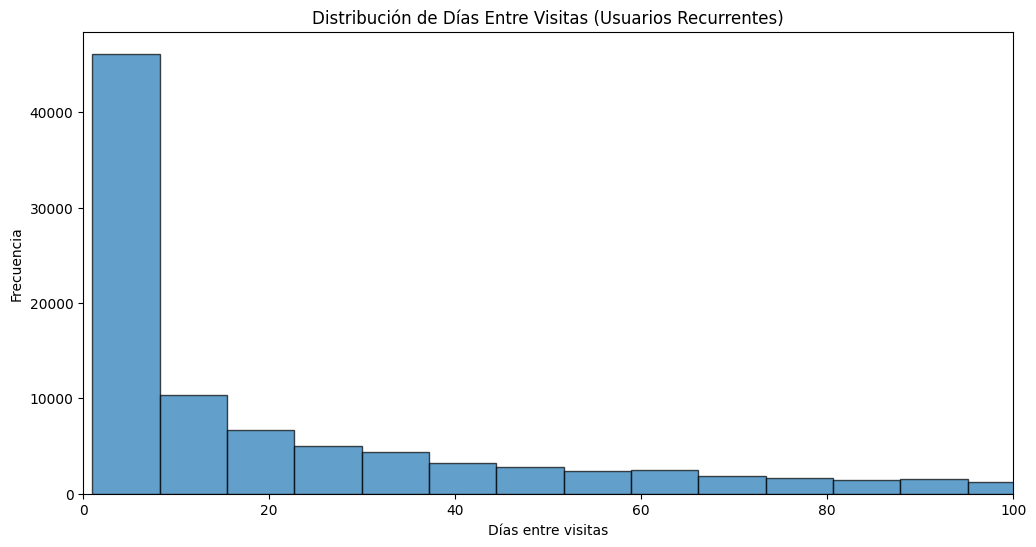

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Convertir a array para análisis
intervalos_array = np.array(todos_los_intervalos)

# Estadísticas básicas
print(f"Promedio de días entre visitas: {intervalos_array.mean():.1f} días")
print(f"Mediana de días entre visitas: {np.median(intervalos_array):.1f} días")
print(f"Intervalo más común: {np.bincount(intervalos_array).argmax()} días")

# Histograma de frecuencia de retorno
plt.figure(figsize=(12, 6))
plt.hist(intervalos_array, bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribución de Días Entre Visitas (Usuarios Recurrentes)')
plt.xlabel('Días entre visitas')
plt.ylabel('Frecuencia')
plt.xlim(0, 100)  # Limitar a primeros 100 días para mejor visualización
plt.show()

El promedio de días entre visitas es de 36 días, existe un patrón relativo, por lo general, los usuarios regresan cada 12 días, es de un tiempo moderado de retorno
Los resultados nos dicen mucho sobre la lealtad y hábitos de uso de los usuarios de Showz.
*   Los usuarios que regresan son más valiosos
*   Es más barato retener que adquirir nuevos usuarios
*   Las sesiones largas muestran que hay usuarios comprometidos, asi como muestran que muchos están explorando el sitio
*   Las sesiones cortas muestran que los usuarios salen rápido, probablemente sea con el uso de la página

## Ventas
Es importante saber el tiempo que transcurre entre el registro y la conversión, es decir, cuando el usuario se convierte en cliente. Por ejemplo, si el registro y la primera compra ocurren el mismo día, el usuario podría caer en la categoría 

*   Conversion 0d: Usuario se registra/visita y compra el mismo día
*   Conversion 1d: Usuario compra al día siguiente de su primera visita
*   Conversion 7d: Usuario compra una semana después
*   Conversion 30d: Usuario compra un mes después

Para saber las conversiones adecuadas, es importante, primero identificar la primera compra de cada usuario, es por ello que se ha preparado primero los datos de ordenes, cambiando el formato de fecha al adecuado

In [22]:
# Convertir Buy Ts a datetime
orders_log['Buy Ts'] = pd.to_datetime(orders_log['Buy Ts'])
orders_log['buy_date'] = orders_log['Buy Ts'].dt.date

# Verificar los datos
print("Datos de órdenes:")
print(orders_log.head())
print(f"\nTotal de órdenes: {len(orders_log):,}")
print(f"Usuarios únicos que compraron: {orders_log['Uid'].nunique():,}")

Datos de órdenes:
               Buy Ts  Revenue                   Uid    buy_date
0 2017-06-01 00:10:00    17.00  10329302124590727494  2017-06-01
1 2017-06-01 00:25:00     0.55  11627257723692907447  2017-06-01
2 2017-06-01 00:27:00     0.37  17903680561304213844  2017-06-01
3 2017-06-01 00:29:00     0.55  16109239769442553005  2017-06-01
4 2017-06-01 07:58:00     0.37  14200605875248379450  2017-06-01

Total de órdenes: 50,415
Usuarios únicos que compraron: 36,523


In [23]:
# Encontrar la primera compra de cada usuario
primera_compra_por_usuario = orders_log.groupby('Uid')['Buy Ts'].min().reset_index()
primera_compra_por_usuario.columns = ['Uid', 'primera_compra_fecha']

# Agregar información adicional de la primera compra
primera_compra_completa = orders_log.merge(
    primera_compra_por_usuario, 
    left_on=['Uid', 'Buy Ts'], 
    right_on=['Uid', 'primera_compra_fecha']
)

print("Primera compra de cada usuario:")
print(primera_compra_completa.head())
print(f"\nTotal de usuarios que hicieron primera compra: {len(primera_compra_completa):,}")

Primera compra de cada usuario:
               Buy Ts  Revenue                   Uid    buy_date  \
0 2017-06-01 00:10:00    17.00  10329302124590727494  2017-06-01   
1 2017-06-01 00:25:00     0.55  11627257723692907447  2017-06-01   
2 2017-06-01 00:27:00     0.37  17903680561304213844  2017-06-01   
3 2017-06-01 00:29:00     0.55  16109239769442553005  2017-06-01   
4 2017-06-01 07:58:00     0.37  14200605875248379450  2017-06-01   

  primera_compra_fecha  
0  2017-06-01 00:10:00  
1  2017-06-01 00:25:00  
2  2017-06-01 00:27:00  
3  2017-06-01 00:29:00  
4  2017-06-01 07:58:00  

Total de usuarios que hicieron primera compra: 36,523


Estadísticas de la primera compra:
Valor promedio de primera compra: $4.14
Valor mediano de primera compra: $2.44
Valor mínimo: $0.00
Valor máximo: $1109.10


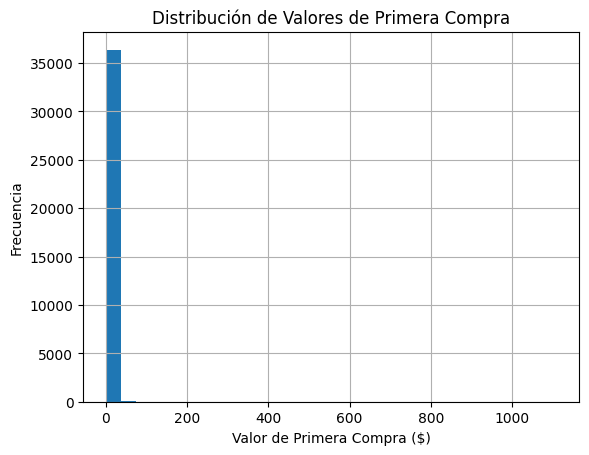

In [24]:
# Estadísticas de la primera compra
print("Estadísticas de la primera compra:")
print(f"Valor promedio de primera compra: ${primera_compra_completa['Revenue'].mean():.2f}")
print(f"Valor mediano de primera compra: ${primera_compra_completa['Revenue'].median():.2f}")
print(f"Valor mínimo: ${primera_compra_completa['Revenue'].min():.2f}")
print(f"Valor máximo: ${primera_compra_completa['Revenue'].max():.2f}")

# Distribución de valores de primera compra
primera_compra_completa['Revenue'].hist(bins=30,) 
plt.title('Distribución de Valores de Primera Compra')
plt.xlabel('Valor de Primera Compra ($)')
plt.ylabel('Frecuencia')
plt.show()

Los datos muestran que alrededor de 36523 usuarios compraron una vez, el valor promedio de la primera compra es de sólo 4.14, es común que la mayoría de los usuarios hagan compras baratas por primera vez

### Primera visita de cada usuario

Se calculó el tiempo de conversión para saber cuántos días pasaron entre la primera visita y la primera compra. Esto es clave para entender el comportamiento de compra de los usuarios.

In [25]:
# Encontrar la primera visita de cada usuario
primera_visita_por_usuario = visits_log.groupby('Uid')['Start Ts'].min().reset_index()
primera_visita_por_usuario.columns = ['Uid', 'primera_visita_fecha']

print("Primera visita de cada usuario:")
print(primera_visita_por_usuario.head())
print(f"\nTotal de usuarios que visitaron: {len(primera_visita_por_usuario):,}")

Primera visita de cada usuario:
               Uid primera_visita_fecha
0   11863502262781  2018-03-01 17:27:00
1   49537067089222  2018-02-06 15:55:00
2  297729379853735  2017-06-07 18:47:00
3  313578113262317  2017-09-18 22:49:00
4  325320750514679  2017-09-30 14:29:00

Total de usuarios que visitaron: 228,169


In [26]:
# Combinar primera visita con primera compra
conversion_data = primera_compra_por_usuario.merge(
    primera_visita_por_usuario, 
    on='Uid', 
    how='inner'  # Solo usuarios que tanto visitaron como compraron
)

print("Datos combinados de conversión:")
print(conversion_data.head())
print(f"\nUsuarios que visitaron Y compraron: {len(conversion_data):,}")

Datos combinados de conversión:
                Uid primera_compra_fecha primera_visita_fecha
0   313578113262317  2018-01-03 21:51:00  2017-09-18 22:49:00
1  1575281904278712  2017-06-03 10:13:00  2017-06-03 10:13:00
2  2429014661409475  2017-10-11 18:33:00  2017-10-11 17:14:00
3  2464366381792757  2018-01-28 15:54:00  2018-01-27 20:10:00
4  2551852515556206  2017-11-24 10:14:00  2017-11-24 10:14:00

Usuarios que visitaron Y compraron: 36,523


In [27]:
# Calcular días de conversión
conversion_data['dias_conversion'] = (
    conversion_data['primera_compra_fecha'] - conversion_data['primera_visita_fecha']
).dt.days

# Estadísticas básicas
print("Estadísticas de tiempo de conversión:")
print(f"Promedio de días para convertir: {conversion_data['dias_conversion'].mean():.1f} días")
print(f"Mediana de días para convertir: {conversion_data['dias_conversion'].median():.1f} días")
print(f"Conversión más rápida: {conversion_data['dias_conversion'].min()} días")
print(f"Conversión más lenta: {conversion_data['dias_conversion'].max()} días")

# Distribución de conversiones
print("\nDistribución de conversiones:")
conversion_counts = conversion_data['dias_conversion'].value_counts().sort_index().head(10)
print(conversion_counts)

Estadísticas de tiempo de conversión:
Promedio de días para convertir: 16.7 días
Mediana de días para convertir: 0.0 días
Conversión más rápida: 0 días
Conversión más lenta: 363 días

Distribución de conversiones:
0    26363
1     1011
2      563
3      434
4      324
5      270
6      260
7      218
8      189
9      140
Name: dias_conversion, dtype: int64


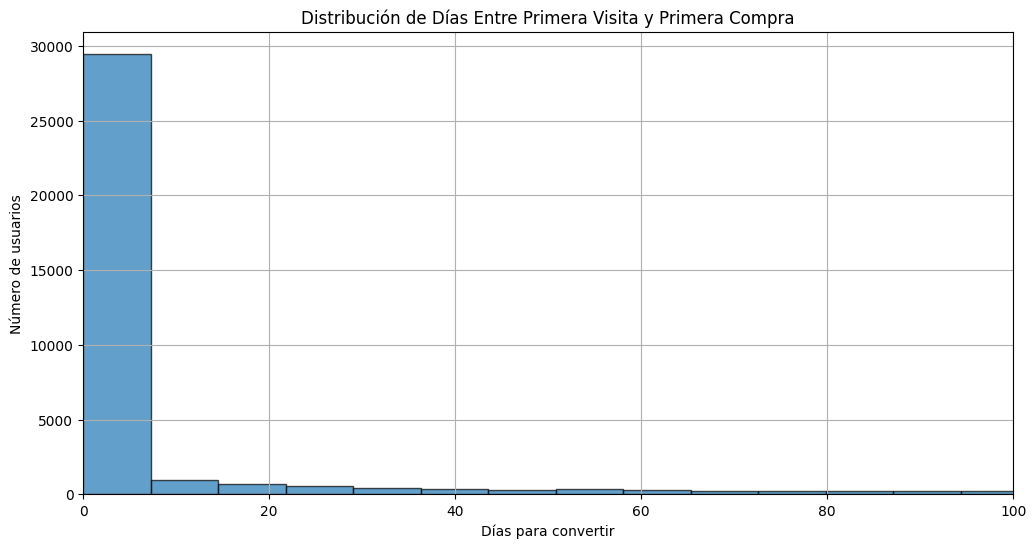

In [28]:
# Histograma de días de conversión
plt.figure(figsize=(12, 6))
conversion_data['dias_conversion'].hist(bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribución de Días Entre Primera Visita y Primera Compra')
plt.xlabel('Días para convertir')
plt.ylabel('Número de usuarios')
plt.xlim(0, 100)  # Limitar a primeros 100 días
plt.show()

De los 228169 usuarios que visitaron la página, sólo 36523 compraron, la mayoría compra en el mismo día,  muy pocos que dejan tiempo para realizar la compra, máximo es 1 día. Esto demuestra que los usuarios prefieren comprar en ese instante

### Número de pedidos por periodo

Se análizo el número de pedidos por periodo, esto nos muestra si los usuarios compran una vez o son compradores recurrentes, analizando los pedidos por usuario, clasificando los tipos de compradores, realizando tambien un analisis temporal de pedidos, asi como la frecuencia de compra de usuarios recurrentes

In [29]:
# Contar cuántos pedidos hace cada usuario
pedidos_por_usuario = orders_log.groupby('Uid').size()

print("Distribución de pedidos por usuario:")
print(pedidos_por_usuario.value_counts().sort_index().head(10))

# Estadísticas básicas
print(f"\nPromedio de pedidos por usuario: {pedidos_por_usuario.mean():.2f}")
print(f"Mediana de pedidos por usuario: {pedidos_por_usuario.median():.1f}")
print(f"Usuario con más pedidos: {pedidos_por_usuario.max()} pedidos")

Distribución de pedidos por usuario:
1     30231
2      4395
3      1086
4       375
5       147
6        79
7        41
8        24
9         7
10       15
dtype: int64

Promedio de pedidos por usuario: 1.38
Mediana de pedidos por usuario: 1.0
Usuario con más pedidos: 239 pedidos


Clasificación de compradores:
Usuarios con 1 pedido: 30,231 (82.8%)
Usuarios con 2 pedidos: 4,395 (12.0%)
Usuarios con 3+ pedidos: 1,897 (5.2%)


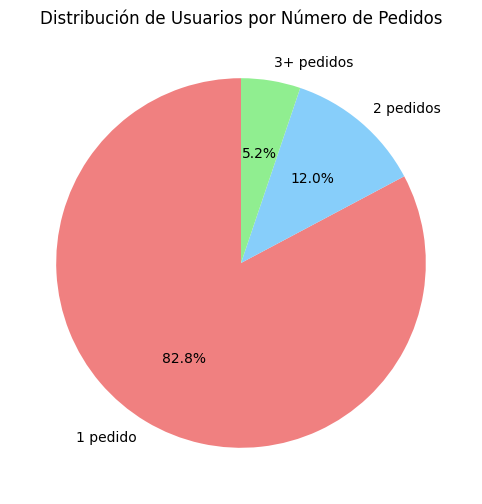

In [30]:
# Clasificar usuarios por comportamiento de compra
usuarios_1_pedido = (pedidos_por_usuario == 1).sum()
usuarios_2_pedidos = (pedidos_por_usuario == 2).sum()
usuarios_3_mas_pedidos = (pedidos_por_usuario >= 3).sum()

print("Clasificación de compradores:")
print(f"Usuarios con 1 pedido: {usuarios_1_pedido:,} ({usuarios_1_pedido/len(pedidos_por_usuario)*100:.1f}%)")
print(f"Usuarios con 2 pedidos: {usuarios_2_pedidos:,} ({usuarios_2_pedidos/len(pedidos_por_usuario)*100:.1f}%)")
print(f"Usuarios con 3+ pedidos: {usuarios_3_mas_pedidos:,} ({usuarios_3_mas_pedidos/len(pedidos_por_usuario)*100:.1f}%)")

# Visualizar
import matplotlib.pyplot as plt
labels = ['1 pedido', '2 pedidos', '3+ pedidos']
sizes = [usuarios_1_pedido, usuarios_2_pedidos, usuarios_3_mas_pedidos]
colors = ['lightcoral', 'lightskyblue', 'lightgreen']

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Distribución de Usuarios por Número de Pedidos')
plt.show()

Se muestra que hay diferentes comportamientos de compra:

*  82.8% hacen solo 1 pedido
*  12.0% hacen 2 pedidos
*  5.2% hacen 3+ pedidos 

## Días entre compras consecutivas para usuarios recurrentes

Se identificó que el 17.2% de los usuarios hacen más de 2 pedidos, asi que se estudió su comportamiento de compra, calculando los días entre compras consecutivas, y analizando su frecuencia de compora

Pedidos por mes:
month_name
April        3273
August       1807
December     6218
February     5281
January      4721
July         2363
June         2355
March        5326
May          4346
November     5659
October      5679
September    3387
dtype: int64


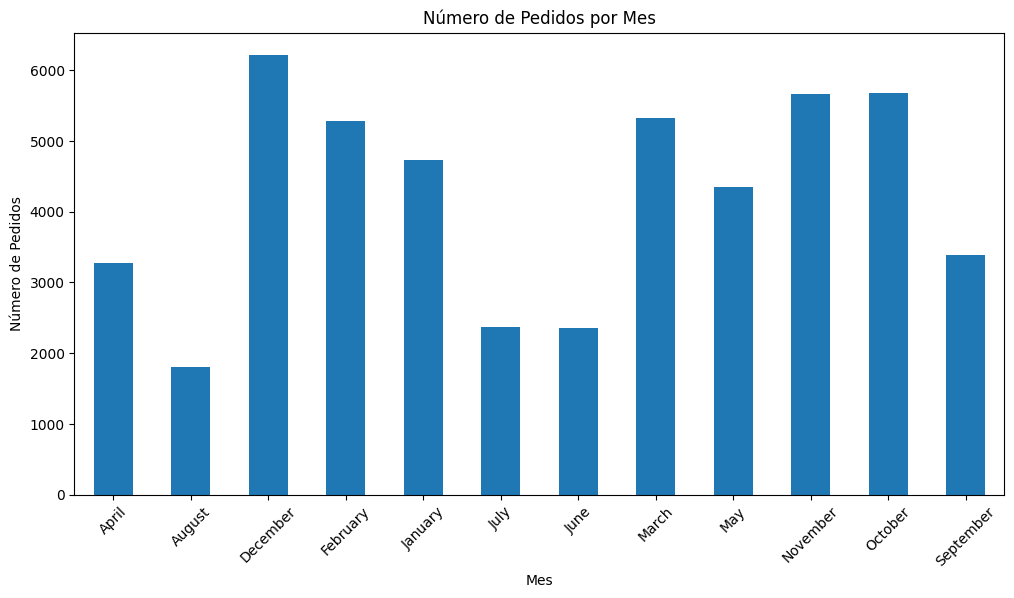

In [31]:
# Agregar columnas de tiempo
orders_log['month'] = orders_log['Buy Ts'].dt.month
orders_log['month_name'] = orders_log['Buy Ts'].dt.month_name()
orders_log['week'] = orders_log['Buy Ts'].dt.isocalendar().week

# Pedidos por mes
pedidos_por_mes = orders_log.groupby('month_name').size()
print("Pedidos por mes:")
print(pedidos_por_mes)

# Visualizar pedidos por mes
plt.figure(figsize=(12, 6))
pedidos_por_mes.plot(kind='bar')
plt.title('Número de Pedidos por Mes')
plt.xlabel('Mes')
plt.ylabel('Número de Pedidos')
plt.xticks(rotation=45)
plt.show()

In [32]:
# Identificar usuarios con 2 o más pedidos
usuarios_recurrentes = pedidos_por_usuario[pedidos_por_usuario >= 2].index
print(f"Usuarios recurrentes (2+ pedidos): {len(usuarios_recurrentes):,}")

# Filtrar órdenes solo de usuarios recurrentes
orders_recurrentes = orders_log[orders_log['Uid'].isin(usuarios_recurrentes)]
print(f"Total de órdenes de usuarios recurrentes: {len(orders_recurrentes):,}")

Usuarios recurrentes (2+ pedidos): 6,292
Total de órdenes de usuarios recurrentes: 20,184


In [33]:
def calcular_dias_entre_compras(user_orders):
    """Calcula días entre compras consecutivas para un usuario"""
    fechas_compra = sorted(user_orders['Buy Ts'].unique())
    if len(fechas_compra) < 2:
        return []
    
    dias_entre_compras = []
    for i in range(1, len(fechas_compra)):
        dias = (pd.to_datetime(fechas_compra[i]) - pd.to_datetime(fechas_compra[i-1])).days
        dias_entre_compras.append(dias)
    
    return dias_entre_compras

# Aplicar función a cada usuario recurrente
todos_los_intervalos_compras = []
for uid in usuarios_recurrentes:
    user_orders = orders_recurrentes[orders_recurrentes['Uid'] == uid]
    intervalos = calcular_dias_entre_compras(user_orders)
    todos_los_intervalos_compras.extend(intervalos)

print(f"Total de intervalos entre compras: {len(todos_los_intervalos_compras):,}")

Total de intervalos entre compras: 13,892


In [34]:
import numpy as np

# Convertir a array para análisis
intervalos_compras = np.array(todos_los_intervalos_compras)

# Estadísticas básicas
print("=== FRECUENCIA DE COMPRA - USUARIOS RECURRENTES ===")
print(f"Promedio de días entre compras: {intervalos_compras.mean():.1f} días")
print(f"Mediana de días entre compras: {np.median(intervalos_compras):.1f} días")
print(f"Intervalo más común: {np.bincount(intervalos_compras).argmax()} días")
print(f"Compra más rápida: {intervalos_compras.min()} días")
print(f"Compra más lenta: {intervalos_compras.max()} días")

# Distribución de frecuencias
print("\n=== TOP 10 INTERVALOS MÁS COMUNES ===")
unique, counts = np.unique(intervalos_compras, return_counts=True)
top_intervals = sorted(zip(unique, counts), key=lambda x: x[1], reverse=True)[:10]

for dias, frecuencia in top_intervals:
    porcentaje = (frecuencia / len(intervalos_compras)) * 100
    print(f"{dias} días: {frecuencia:,} casos ({porcentaje:.1f}%)")

# Análisis por categorías de frecuencia
print("\n=== CATEGORÍAS DE FRECUENCIA ===")
compras_mismo_dia = (intervalos_compras == 0).sum()
compras_1_semana = (intervalos_compras <= 7).sum()
compras_1_mes = (intervalos_compras <= 30).sum()
compras_mas_mes = (intervalos_compras > 30).sum()

print(f"Compras el mismo día (0d): {compras_mismo_dia:,} ({compras_mismo_dia/len(intervalos_compras)*100:.1f}%)")
print(f"Compras en 1 semana (≤7d): {compras_1_semana:,} ({compras_1_semana/len(intervalos_compras)*100:.1f}%)")
print(f"Compras en 1 mes (≤30d): {compras_1_mes:,} ({compras_1_mes/len(intervalos_compras)*100:.1f}%)")
print(f"Compras después de 1 mes (>30d): {compras_mas_mes:,} ({compras_mas_mes/len(intervalos_compras)*100:.1f}%)")

=== FRECUENCIA DE COMPRA - USUARIOS RECURRENTES ===
Promedio de días entre compras: 25.1 días
Mediana de días entre compras: 2.0 días
Intervalo más común: 0 días
Compra más rápida: 0 días
Compra más lenta: 358 días

=== TOP 10 INTERVALOS MÁS COMUNES ===
0 días: 5,263 casos (37.9%)
1 días: 1,275 casos (9.2%)
2 días: 831 casos (6.0%)
3 días: 547 casos (3.9%)
4 días: 362 casos (2.6%)
6 días: 263 casos (1.9%)
7 días: 221 casos (1.6%)
5 días: 216 casos (1.6%)
8 días: 145 casos (1.0%)
9 días: 144 casos (1.0%)

=== CATEGORÍAS DE FRECUENCIA ===
Compras el mismo día (0d): 5,263 (37.9%)
Compras en 1 semana (≤7d): 8,978 (64.6%)
Compras en 1 mes (≤30d): 10,830 (78.0%)
Compras después de 1 mes (>30d): 3,062 (22.0%)


### Visualizaciones de patrones de frecuencia

[Text(0, 0, '0'),
 Text(1, 0, '1'),
 Text(2, 0, '2'),
 Text(3, 0, '3'),
 Text(4, 0, '4'),
 Text(5, 0, '6'),
 Text(6, 0, '7'),
 Text(7, 0, '5'),
 Text(8, 0, '8'),
 Text(9, 0, '9')]

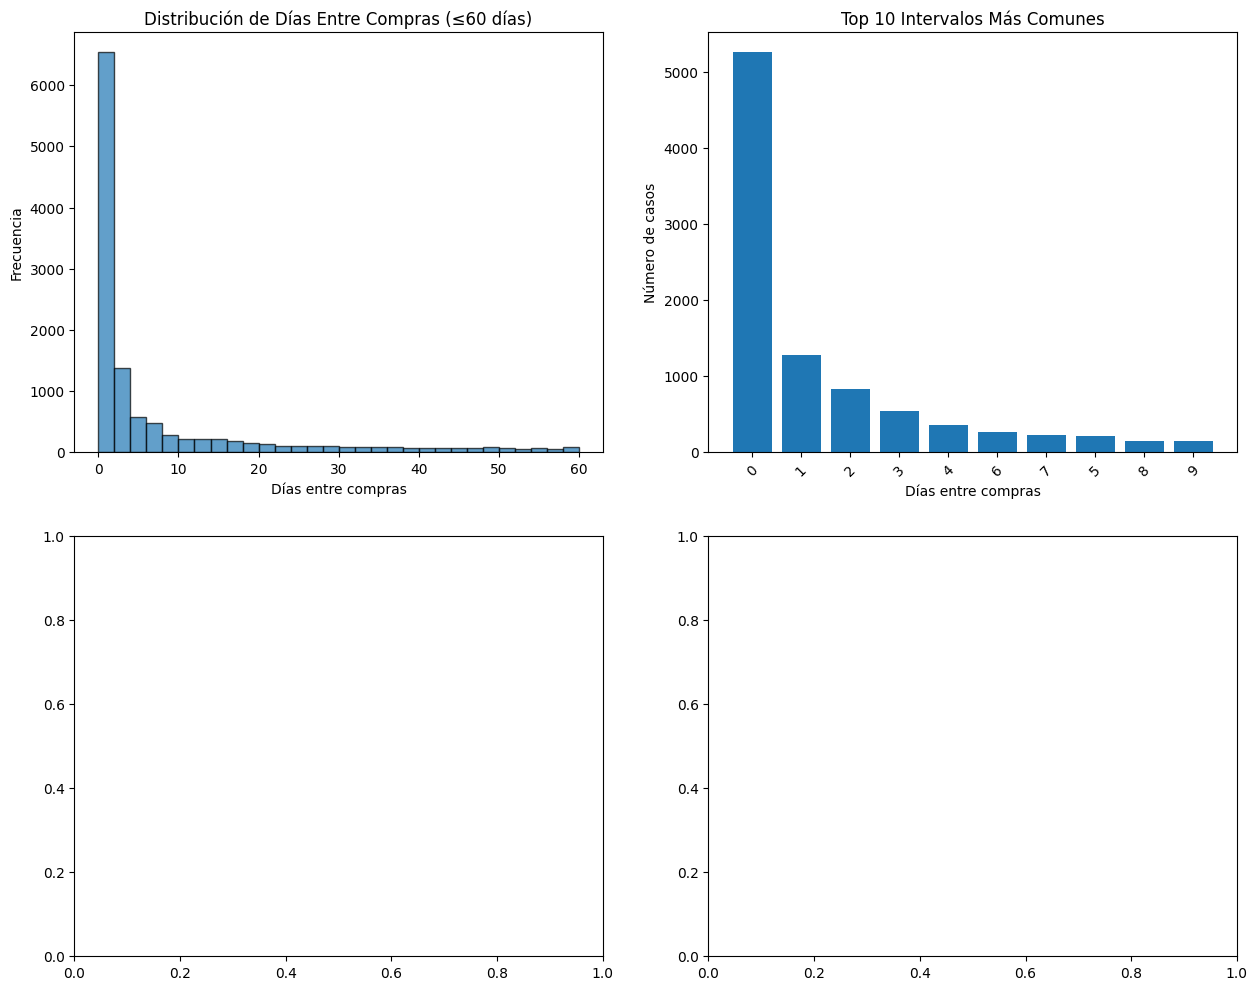

In [35]:
# Crear visualización completa de frecuencia de compra
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Histograma general (primeros 60 días)
axes[0,0].hist(intervalos_compras[intervalos_compras <= 60], bins=30, edgecolor='black', alpha=0.7)
axes[0,0].set_title('Distribución de Días Entre Compras (≤60 días)')
axes[0,0].set_xlabel('Días entre compras')
axes[0,0].set_ylabel('Frecuencia')

# 2. Top 10 intervalos más comunes
top_dias = [x[0] for x in top_intervals]
top_counts = [x[1] for x in top_intervals]
axes[0,1].bar(range(len(top_dias)), top_counts)
axes[0,1].set_title('Top 10 Intervalos Más Comunes')
axes[0,1].set_xlabel('Días entre compras')
axes[0,1].set_ylabel('Número de casos')
axes[0,1].set_xticks(range(len(top_dias)))
axes[0,1].set_xticklabels(top_dias, rotation=45)

El 37.9% de las compras recurrentes ocurren el mismo día, además que el 64.6% ocurren dentro de la primera semana y el promedio es de 25.1 días entre compras

## Ingresos

Para verificar patrones de compra de usuarios recientes, es importane analizarlos para saber el valor económico que generan, para eso se calculó los ingresos por usuario recurrente

In [36]:
# Ingresos por usuario recurrente
ingresos_usuarios_recurrentes = orders_recurrentes.groupby('Uid')['Revenue'].sum()
print(f"Ingreso promedio por usuario recurrente: ${ingresos_usuarios_recurrentes.mean():.2f}")

Ingreso promedio por usuario recurrente: $20.88


## Calcular LTV

El ingreso promedio es de 20.88, en base a eso se hizo un cálculo LTV básico, con la suma total de ingresos por cada usuario 


In [37]:
# Calcular LTV por usuario (suma total de todas sus compras)
ltv_por_usuario = orders_log.groupby('Uid')['Revenue'].sum()

print("=== ANÁLISIS DE LTV ===")
print(f"LTV promedio: ${ltv_por_usuario.mean():.2f}")
print(f"LTV mediano: ${ltv_por_usuario.median():.2f}")
print(f"LTV mínimo: ${ltv_por_usuario.min():.2f}")
print(f"LTV máximo: ${ltv_por_usuario.max():.2f}")

=== ANÁLISIS DE LTV ===
LTV promedio: $6.90
LTV mediano: $3.05
LTV mínimo: $0.00
LTV máximo: $11810.18


El valor típico de un cliente para Showz es de 6.90, existe variación entre clientes, ya que algunos clientes son más valiosos, de hecho, el LTV máximo es de $ 11810

## LTV por dispositivo

Se analizó el LTV por dispositivo para entender si los usuarios de diferentes dispositivos tienen diferente valor económico, para eso se conectó los datos de dispositivo en órdenes, combinándose con la Ltv

In [38]:
# Obtener el dispositivo de cada usuario (su primera visita)
dispositivo_por_usuario = visits_log.groupby('Uid')['Device'].first().reset_index()
print("Dispositivos por usuario:")
print(dispositivo_por_usuario['Device'].value_counts())

Dispositivos por usuario:
desktop    160947
touch       67222
Name: Device, dtype: int64


In [39]:
# Convertir LTV a DataFrame para facilitar el merge
ltv_df = ltv_por_usuario.reset_index()
ltv_df.columns = ['Uid', 'LTV']

# Combinar LTV con dispositivo
ltv_por_dispositivo_df = ltv_df.merge(dispositivo_por_usuario, on='Uid', how='left')

print("Datos combinados:")
print(ltv_por_dispositivo_df.head())
print(f"\nTotal de usuarios con LTV y dispositivo: {len(ltv_por_dispositivo_df):,}")

Datos combinados:
                Uid    LTV   Device
0   313578113262317   0.55  desktop
1  1575281904278712   3.05    touch
2  2429014661409475  73.33  desktop
3  2464366381792757   2.44  desktop
4  2551852515556206  10.99  desktop

Total de usuarios con LTV y dispositivo: 36,523


In [40]:
# Calcular estadísticas de LTV por dispositivo
ltv_stats_dispositivo = ltv_por_dispositivo_df.groupby('Device')['LTV'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2)

print("=== LTV POR DISPOSITIVO ===")
print(ltv_stats_dispositivo)

# Calcular LTV promedio por dispositivo
ltv_promedio_dispositivo = ltv_por_dispositivo_df.groupby('Device')['LTV'].mean()
print(f"\n=== LTV PROMEDIO POR DISPOSITIVO ===")
for dispositivo, ltv_avg in ltv_promedio_dispositivo.items():
    print(f"{dispositivo}: ${ltv_avg:.2f}")

=== LTV POR DISPOSITIVO ===
         count  mean  median    std  min       max
Device                                            
desktop  29222  7.24    3.05  97.76  0.0  11810.18
touch     7301  5.55    2.75  24.40  0.0   1163.63

=== LTV PROMEDIO POR DISPOSITIVO ===
desktop: $7.24
touch: $5.55


La mayoría usa un ordenador,  y el LTV máximo de este es de 11810,  la cantidad de LTV de ordenador es de 29222 y el táctil, es de 7301, por lo cual, hay más valor en los usuarios de ordenador

## LTV por fuente de anuncios

¿Qué canales de marketing traen los clientes más valiosos?, para saber eso, se calculó el LTV por los usuarios y sus compras, las fuente de anuncios de cada usuario, en base al LTV calculado

In [41]:
# Obtener la fuente de anuncios de cada usuario (su primera visita)
fuente_por_usuario = visits_log.groupby('Uid')['Source Id'].first().reset_index()
print("Fuentes de anuncios por usuario:")
print(fuente_por_usuario['Source Id'].value_counts().sort_index())

Fuentes de anuncios por usuario:
1     11746
2     19389
3     62674
4     71905
5     48884
6         3
7        33
9      6770
10     6765
Name: Source Id, dtype: int64


In [42]:
# Combinar LTV con fuente de anuncios
ltv_por_fuente_df = ltv_df.merge(fuente_por_usuario, on='Uid', how='left')
print("Datos combinados:")
print(ltv_por_fuente_df.head())
print(f"\nTotal de usuarios con LTV y fuente: {len(ltv_por_fuente_df):,}")

Datos combinados:
                Uid    LTV  Source Id
0   313578113262317   0.55          2
1  1575281904278712   3.05         10
2  2429014661409475  73.33          3
3  2464366381792757   2.44          5
4  2551852515556206  10.99          5

Total de usuarios con LTV y fuente: 36,523


In [43]:
# Calcular LTV promedio por fuente de anuncios
ltv_promedio_fuente = ltv_por_fuente_df.groupby('Source Id')['LTV'].mean().sort_values(ascending=False)
print("=== LTV PROMEDIO POR FUENTE DE ANUNCIOS ===")
for fuente, ltv_avg in ltv_promedio_fuente.items():
    print(f"Fuente {fuente}: ${ltv_avg:.2f}")

=== LTV PROMEDIO POR FUENTE DE ANUNCIOS ===
Fuente 2: $15.07
Fuente 1: $10.30
Fuente 5: $5.90
Fuente 4: $5.34
Fuente 9: $5.00
Fuente 3: $4.85
Fuente 10: $3.31
Fuente 7: $1.22


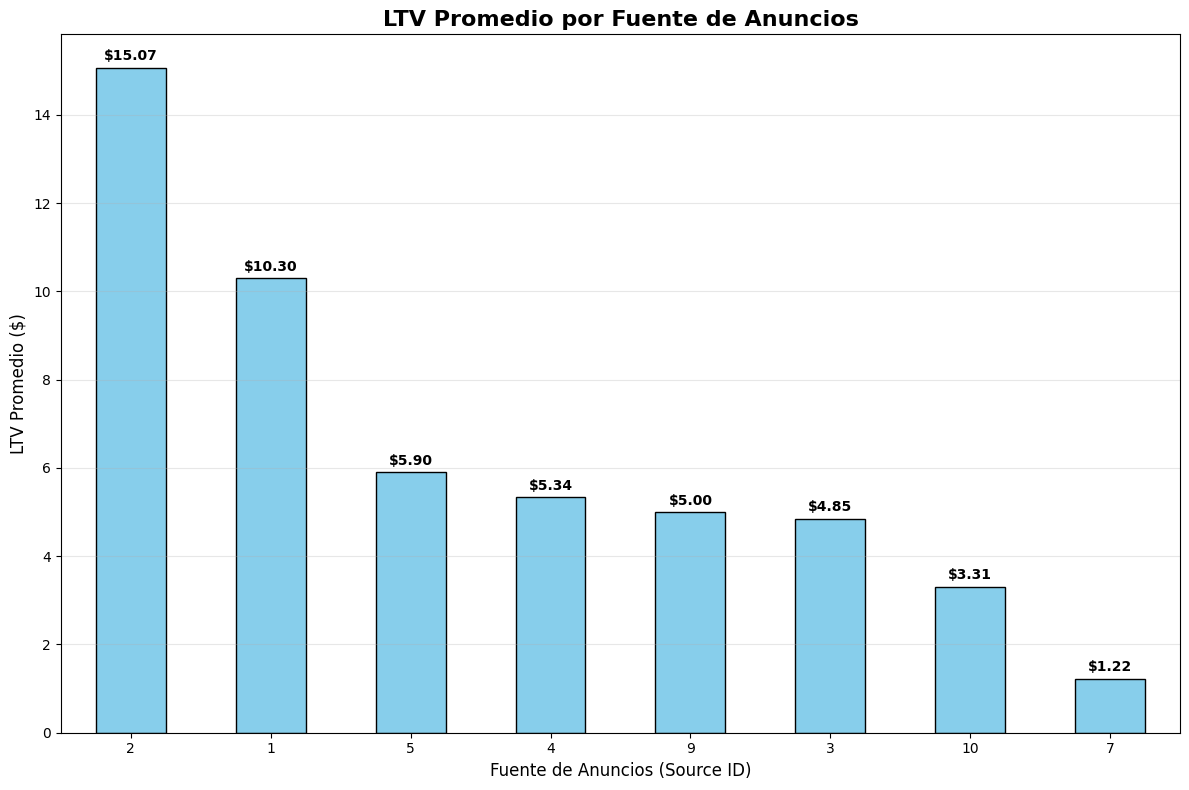

In [44]:
# Crear gráfico de barras comparando LTV promedio por fuente
plt.figure(figsize=(12, 8))
ltv_promedio_fuente.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('LTV Promedio por Fuente de Anuncios', fontsize=16, fontweight='bold')
plt.xlabel('Fuente de Anuncios (Source ID)', fontsize=12)
plt.ylabel('LTV Promedio ($)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for i, v in enumerate(ltv_promedio_fuente.values):
    plt.text(i, v + 0.1, f'${v:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

La fuente 2 de anuncios tiene el LTV más alto, Hay diferencias significativas entre otras fuentes, ya que la mayoría no sobrepasa los $11, algunas fuentes traen pocos usuarios pero son muy valiosos

## Marketing

### ¿Cuánto dinero se gastó en total?

Se analizaron los gastos de marketing, asi como cuanto se gastó por fuente de adquisición

In [ ]:
# Análisis básico de gastos de marketing
print("=== ANÁLISIS DE GASTOS DE MARKETING ===")
print(f"Gasto total: ${costs['costs'].sum():,.2f}")
print(f"Gasto promedio diario: ${costs['costs'].mean():.2f}")
print(f"Gasto mínimo diario: ${costs['costs'].min():.2f}")
print(f"Gasto máximo diario: ${costs['costs'].max():.2f}")
print(f"Número total de días con gastos: {len(costs):,}")

=== ANÁLISIS DE GASTOS DE MARKETING ===
Gasto total: $329,131.62
Gasto promedio diario: $129.48
Gasto mínimo diario: $0.54
Gasto máximo diario: $1788.28
Número total de días con gastos: 2,542



=== GASTOS POR FUENTE DE ANUNCIOS ===
Fuente 3: $141,321.63 (42.9%)
Fuente 4: $61,073.60 (18.6%)
Fuente 5: $51,757.10 (15.7%)
Fuente 2: $42,806.04 (13.0%)
Fuente 1: $20,833.27 (6.3%)
Fuente 10: $5,822.49 (1.8%)
Fuente 9: $5,517.49 (1.7%)


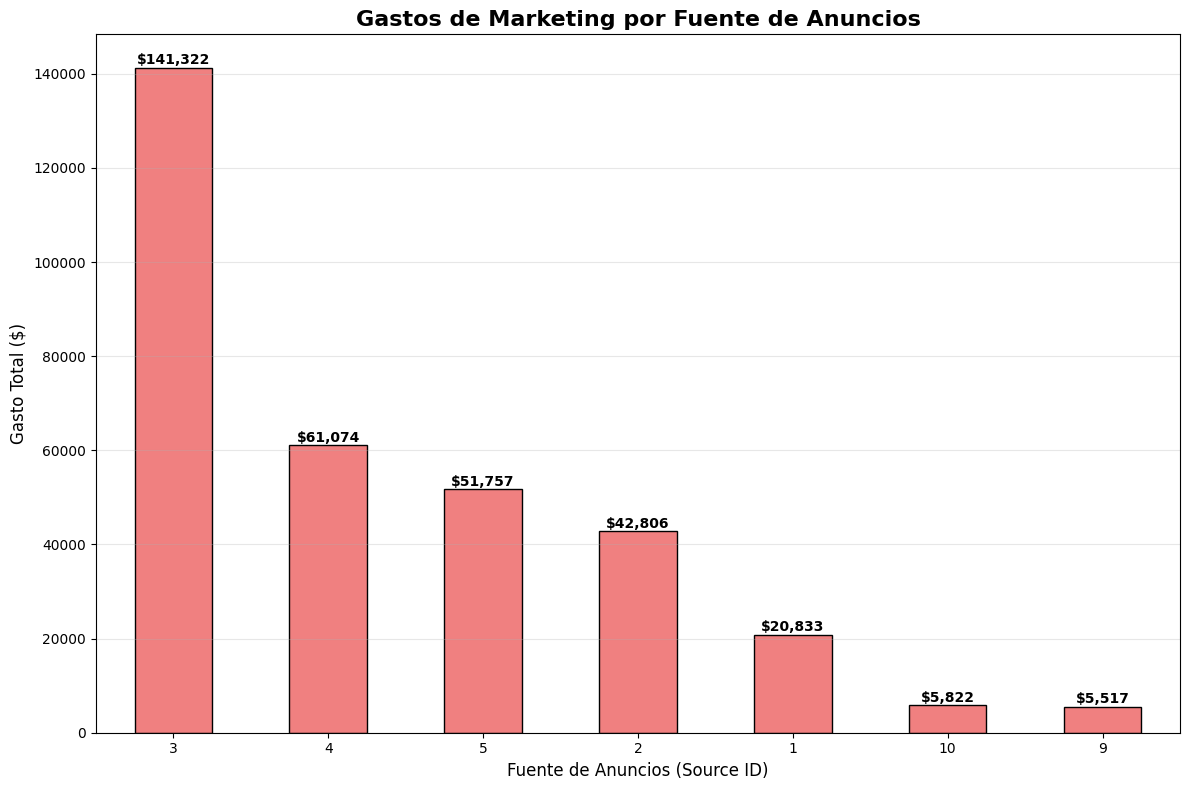

In [ ]:
# Gastos por fuente de anuncios
gastos_por_fuente = costs.groupby('source_id')['costs'].sum().sort_values(ascending=False)
print("\n=== GASTOS POR FUENTE DE ANUNCIOS ===")
for fuente, gasto in gastos_por_fuente.items():
    porcentaje = (gasto / costs['costs'].sum()) * 100
    print(f"Fuente {fuente}: ${gasto:,.2f} ({porcentaje:.1f}%)")

# Crear gráfico de barras
plt.figure(figsize=(12, 8))
gastos_por_fuente.plot(kind='bar', color='lightcoral', edgecolor='black')
plt.title('Gastos de Marketing por Fuente de Anuncios', fontsize=16, fontweight='bold')
plt.xlabel('Fuente de Anuncios (Source ID)', fontsize=12)
plt.ylabel('Gasto Total ($)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for i, v in enumerate(gastos_por_fuente.values):
    plt.text(i, v + 100, f'${v:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


=== GASTOS POR MES ===
2017-06: $18,015.00
2017-07: $18,240.59
2017-08: $14,790.54
2017-09: $24,368.91
2017-10: $36,322.88
2017-11: $37,907.88
2017-12: $38,315.35
2018-01: $33,518.52
2018-02: $32,723.03
2018-03: $30,415.27
2018-04: $22,289.38
2018-05: $22,224.27


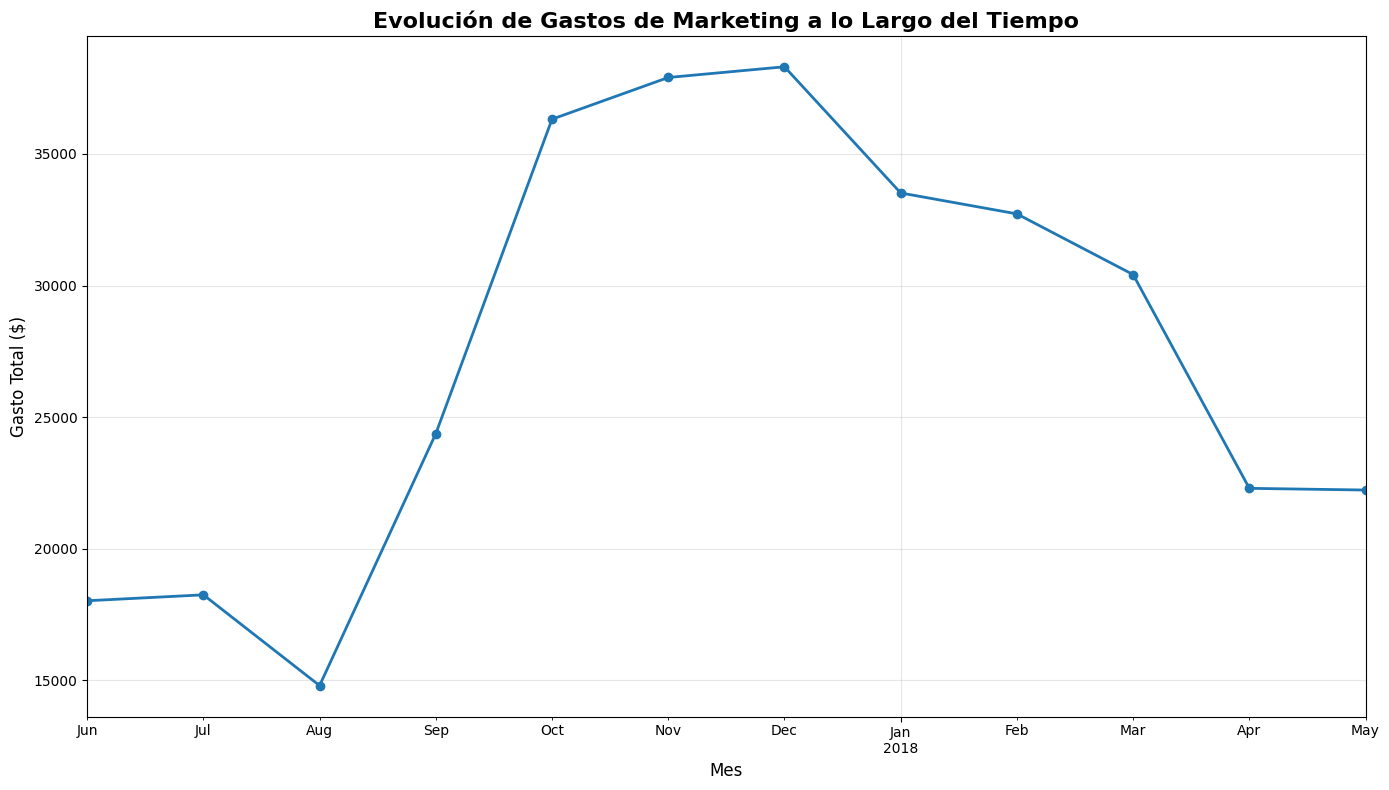

In [ ]:
# Convertir fecha a datetime
costs['dt'] = pd.to_datetime(costs['dt'])
costs['month'] = costs['dt'].dt.to_period('M')

# Gastos por mes
gastos_por_mes = costs.groupby('month')['costs'].sum()
print("\n=== GASTOS POR MES ===")
for mes, gasto in gastos_por_mes.items():
    print(f"{mes}: ${gasto:,.2f}")

# Crear gráfico de líneas
plt.figure(figsize=(14, 8))
gastos_por_mes.plot(kind='line', marker='o', linewidth=2, markersize=6)
plt.title('Evolución de Gastos de Marketing a lo Largo del Tiempo', fontsize=16, fontweight='bold')
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Gasto Total ($)', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

se ha gastado en total, $329131  en marketing, diariamente se gasta en promedio, 129.48, en la fuente de anuncios 3, es donde hay más gastos, durante los últimos 3 meses del 2017 se realizaron más gastos de marketing

## Costo de adquisición de clientes (CAC) por fuente

se realizó el calculo CAC por fuente, y se creó una visualización comparativa

In [49]:
# Contar usuarios únicos por fuente de anuncios
usuarios_por_fuente = fuente_por_usuario['Source Id'].value_counts().sort_index()
print("=== USUARIOS ADQUIRIDOS POR FUENTE ===")
for fuente, usuarios in usuarios_por_fuente.items():
    print(f"Fuente {fuente}: {usuarios:,} usuarios")

# Calcular CAC por fuente
print("\n=== COSTO DE ADQUISICIÓN DE CLIENTES (CAC) POR FUENTE ===")
cac_por_fuente = {}

for fuente in gastos_por_fuente.index:
    if fuente in usuarios_por_fuente.index:
        gasto_total = gastos_por_fuente[fuente]
        usuarios_adquiridos = usuarios_por_fuente[fuente]
        cac = gasto_total / usuarios_adquiridos
        cac_por_fuente[fuente] = cac
        print(f"Fuente {fuente}: ${cac:.2f} por cliente")
        print(f"  - Gasto total: ${gasto_total:,.2f}")
        print(f"  - Usuarios adquiridos: {usuarios_adquiridos:,}")
        print()

=== USUARIOS ADQUIRIDOS POR FUENTE ===
Fuente 1: 11,746 usuarios
Fuente 2: 19,389 usuarios
Fuente 3: 62,674 usuarios
Fuente 4: 71,905 usuarios
Fuente 5: 48,884 usuarios
Fuente 6: 3 usuarios
Fuente 7: 33 usuarios
Fuente 9: 6,770 usuarios
Fuente 10: 6,765 usuarios

=== COSTO DE ADQUISICIÓN DE CLIENTES (CAC) POR FUENTE ===
Fuente 3: $2.25 por cliente
  - Gasto total: $141,321.63
  - Usuarios adquiridos: 62,674

Fuente 4: $0.85 por cliente
  - Gasto total: $61,073.60
  - Usuarios adquiridos: 71,905

Fuente 5: $1.06 por cliente
  - Gasto total: $51,757.10
  - Usuarios adquiridos: 48,884

Fuente 2: $2.21 por cliente
  - Gasto total: $42,806.04
  - Usuarios adquiridos: 19,389

Fuente 1: $1.77 por cliente
  - Gasto total: $20,833.27
  - Usuarios adquiridos: 11,746

Fuente 10: $0.86 por cliente
  - Gasto total: $5,822.49
  - Usuarios adquiridos: 6,765

Fuente 9: $0.81 por cliente
  - Gasto total: $5,517.49
  - Usuarios adquiridos: 6,770



## Comparación de Rentabilidad por Fuente

Se creó una visualización que compara LTV vs CAC por fuente de anuncios:

In [50]:
# Crear DataFrame combinando LTV y CAC por fuente
import pandas as pd
import matplotlib.pyplot as plt

# Convertir a DataFrame para facilitar la visualización
cac_df = pd.DataFrame(list(cac_por_fuente.items()), columns=['Source_Id', 'CAC'])
ltv_fuente_df = ltv_promedio_fuente.reset_index()
ltv_fuente_df.columns = ['Source_Id', 'LTV_promedio']

# Combinar datos
rentabilidad_fuente = cac_df.merge(ltv_fuente_df, on='Source_Id')
rentabilidad_fuente['ROMI'] = rentabilidad_fuente['LTV_promedio'] / rentabilidad_fuente['CAC']

print("Rentabilidad por fuente:")
print(rentabilidad_fuente)

Rentabilidad por fuente:
   Source_Id       CAC  LTV_promedio      ROMI
0          3  2.254869      4.849823  2.150823
1          4  0.849365      5.342538  6.290037
2          5  1.058774      5.901142  5.573562
3          2  2.207749     15.071076  6.826445
4          1  1.773648     10.301913  5.808319
5         10  0.860678      3.312925  3.849202
6          9  0.814991      5.001399  6.136753


## ¿Cuáles fuentes son más rentables?

Se muestra cuáles son las fuentes más rentables

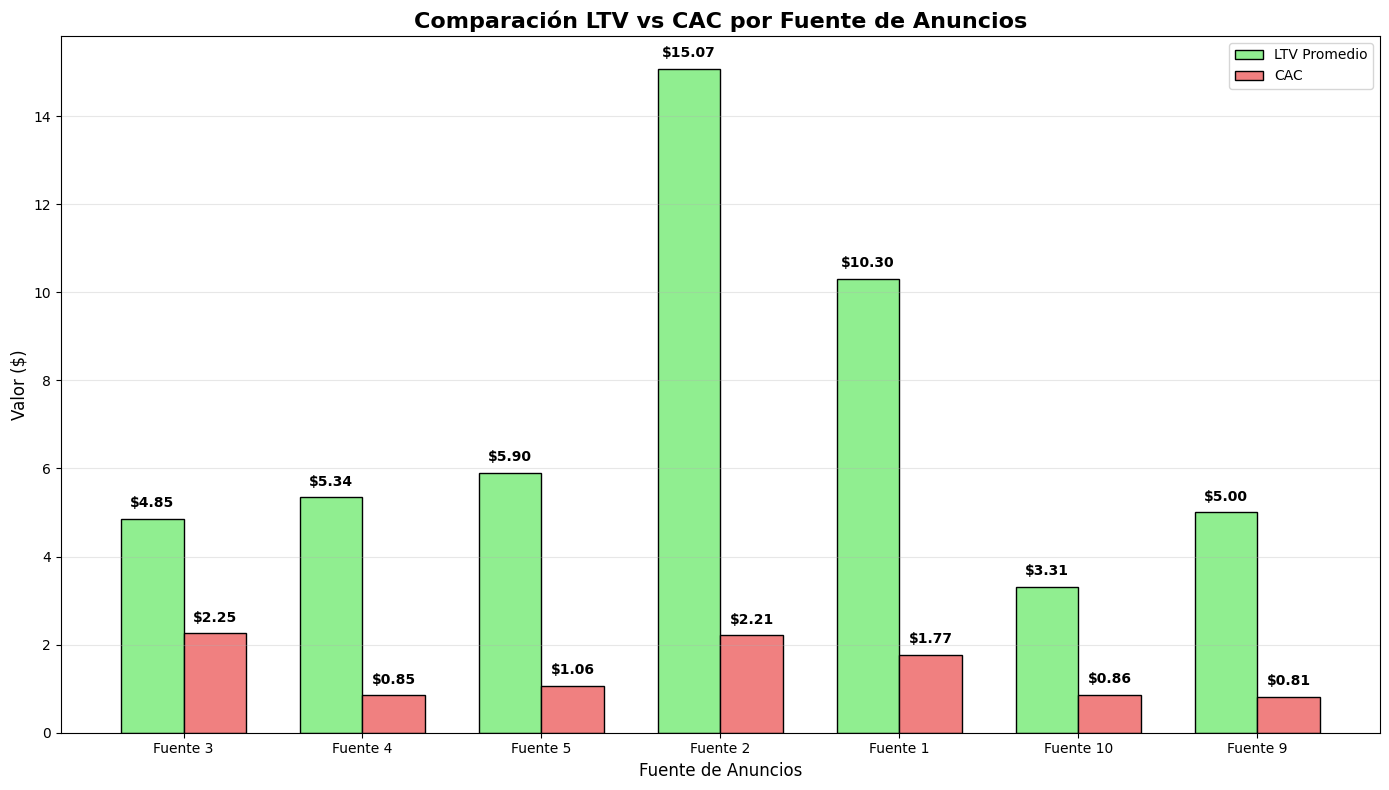

In [51]:
# Crear gráfico comparativo LTV vs CAC
fig, ax = plt.subplots(figsize=(14, 8))

# Configurar posiciones de las barras
x = range(len(rentabilidad_fuente))
width = 0.35

# Crear barras para LTV y CAC
bars1 = ax.bar([i - width/2 for i in x], rentabilidad_fuente['LTV_promedio'], 
               width, label='LTV Promedio', color='lightgreen', edgecolor='black')
bars2 = ax.bar([i + width/2 for i in x], rentabilidad_fuente['CAC'], 
               width, label='CAC', color='lightcoral', edgecolor='black')

# Configurar el gráfico
ax.set_xlabel('Fuente de Anuncios', fontsize=12)
ax.set_ylabel('Valor ($)', fontsize=12)
ax.set_title('Comparación LTV vs CAC por Fuente de Anuncios', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'Fuente {int(id)}' for id in rentabilidad_fuente['Source_Id']])
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for i, (ltv, cac) in enumerate(zip(rentabilidad_fuente['LTV_promedio'], rentabilidad_fuente['CAC'])):
    ax.text(i - width/2, ltv + 0.2, f'${ltv:.2f}', ha='center', va='bottom', fontweight='bold')
    ax.text(i + width/2, cac + 0.2, f'${cac:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

El gráfico muestra que la fuente 2 de anuncios, es muy rentable

## Gráfico de ROMI

Se realizó un gráfico de ROMI para mostrar cuán rentables eran las inversiones? (ROMI)

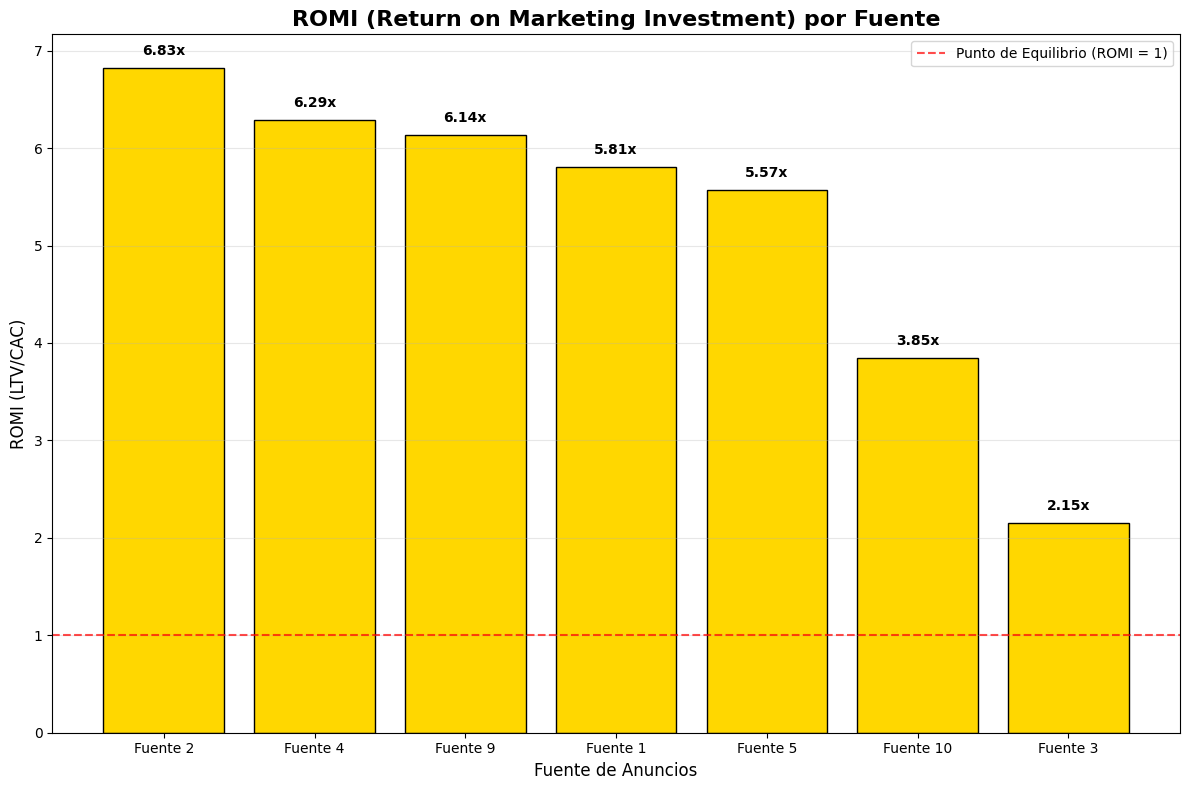

In [53]:
# Ordenar por ROMI para mejor visualización
rentabilidad_ordenada = rentabilidad_fuente.sort_values('ROMI', ascending=False)

# Crear gráfico de ROMI
plt.figure(figsize=(12, 8))
bars = plt.bar(range(len(rentabilidad_ordenada)), rentabilidad_ordenada['ROMI'], 
               color='gold', edgecolor='black')

plt.title('ROMI (Return on Marketing Investment) por Fuente', fontsize=16, fontweight='bold')
plt.xlabel('Fuente de Anuncios', fontsize=12)
plt.ylabel('ROMI (LTV/CAC)', fontsize=12)
plt.xticks(range(len(rentabilidad_ordenada)), 
           [f'Fuente {int(id)}' for id in rentabilidad_ordenada['Source_Id']])
plt.grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for i, v in enumerate(rentabilidad_ordenada['ROMI']):
    plt.text(i, v + 0.1, f'{v:.2f}x', ha='center', va='bottom', fontweight='bold')

# Agregar línea de referencia en ROMI = 1 (punto de equilibrio)
plt.axhline(y=1, color='red', linestyle='--', alpha=0.7, label='Punto de Equilibrio (ROMI = 1)')
plt.legend()

plt.tight_layout()
plt.show()

## Gráfico de Dispersión: Rentabilidad vs Volumen

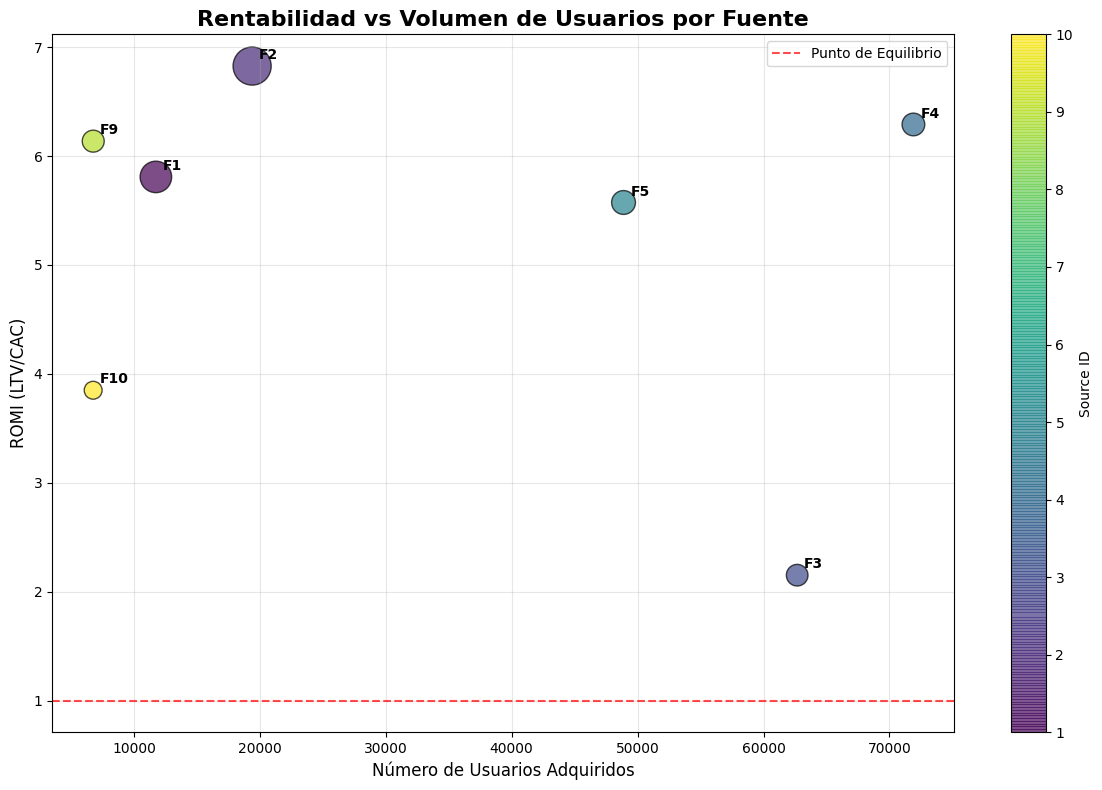

In [54]:
# Agregar número de usuarios por fuente para análisis completo
usuarios_por_fuente_df = usuarios_por_fuente.reset_index()
usuarios_por_fuente_df.columns = ['Source_Id', 'Usuarios']

# Combinar con datos de rentabilidad
analisis_completo = rentabilidad_fuente.merge(usuarios_por_fuente_df, on='Source_Id')

# Crear gráfico de dispersión
plt.figure(figsize=(12, 8))
scatter = plt.scatter(analisis_completo['Usuarios'], analisis_completo['ROMI'], 
                     s=analisis_completo['LTV_promedio']*50, 
                     c=analisis_completo['Source_Id'], 
                     cmap='viridis', alpha=0.7, edgecolors='black')

plt.title('Rentabilidad vs Volumen de Usuarios por Fuente', fontsize=16, fontweight='bold')
plt.xlabel('Número de Usuarios Adquiridos', fontsize=12)
plt.ylabel('ROMI (LTV/CAC)', fontsize=12)
plt.grid(True, alpha=0.3)

# Agregar línea de referencia
plt.axhline(y=1, color='red', linestyle='--', alpha=0.7, label='Punto de Equilibrio')

# Agregar etiquetas para cada fuente
for i, row in analisis_completo.iterrows():
    plt.annotate(f'F{int(row["Source_Id"])}', 
                (row['Usuarios'], row['ROMI']), 
                xytext=(5, 5), textcoords='offset points', fontweight='bold')

plt.colorbar(scatter, label='Source ID')
plt.legend()
plt.tight_layout()
plt.show()

Resumen de Rentabilidad

In [55]:
# Mostrar resumen de rentabilidad
print("=== RESUMEN DE RENTABILIDAD POR FUENTE ===")
print(f"{'Fuente':<8} {'LTV':<8} {'CAC':<8} {'ROMI':<8} {'Usuarios':<10} {'Status'}")
print("-" * 60)

for _, row in analisis_completo.iterrows():
    status = "✅ RENTABLE" if row['ROMI'] > 1 else "❌ NO RENTABLE"
    print(f"{int(row['Source_Id']):<8} ${row['LTV_promedio']:<7.2f} ${row['CAC']:<7.2f} "
          f"{row['ROMI']:<7.2f}x {row['Usuarios']:<10,} {status}")

=== RESUMEN DE RENTABILIDAD POR FUENTE ===
Fuente   LTV      CAC      ROMI     Usuarios   Status
------------------------------------------------------------
3        $4.85    $2.25    2.15   x 62,674.0   ✅ RENTABLE
4        $5.34    $0.85    6.29   x 71,905.0   ✅ RENTABLE
5        $5.90    $1.06    5.57   x 48,884.0   ✅ RENTABLE
2        $15.07   $2.21    6.83   x 19,389.0   ✅ RENTABLE
1        $10.30   $1.77    5.81   x 11,746.0   ✅ RENTABLE
10       $3.31    $0.86    3.85   x 6,765.0    ✅ RENTABLE
9        $5.00    $0.81    6.14   x 6,770.0    ✅ RENTABLE


La fuente que tiene el ROMI más alto, es la fuente 2, con 6.83, la mayoría de las fuentes son rentables, algunas fuentes como la 3 poseen alto volumen pero baja rentabilidad, algunas fuentes pequeñas como la 9, es muy rentable

# Conclusiones

Son recomendables las fuentes 2,4 y 9 para invertir, asi como sale rentable los usuarios de ordenador, ya que de ellos vienen más ingresos, la mayoría hace compras una sola vez, y en ese mismo día, esto basándose en los cálculos de las visitas por mes y las ventas de las mismas